# Entrega Clustering Grupo 16

Integrantes:
- Eduardo Montecinos
- Jose Cristobal Silva
- Matías Toledo

In [1]:
library(cluster)
library(factoextra)
options(scipen = 999)

Warning message:
"package 'cluster' was built under R version 4.4.3"
Warning message:
"package 'factoextra' was built under R version 4.4.3"
Loading required package: ggplot2

Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/



## Ejercicio 1:

V1: área A

V2: perímetro P

V3: longitud de la semilla

V4: ancho de la semilla

V5: coeficiente de asimetría

V6: longitud de la ranura de la semilla

      V1    V2    V3    V4    V5    V6
1  16.63 15.46 6.053 3.465 2.040 5.877
2  20.03 16.90 6.493 3.857 3.063 6.320
3  15.60 15.11 5.832 3.286 2.725 5.752
4  10.82 12.83 5.180 2.630 4.853 5.089
5  14.79 14.52 5.545 3.291 2.704 5.111
6  14.03 14.16 5.438 3.201 1.717 5.001
7  16.44 15.25 5.884 3.505 1.969 5.533
8  13.78 14.06 5.479 3.156 3.136 4.872
9  18.76 16.20 6.172 3.796 3.120 6.053
10 12.88 13.50 5.139 3.119 2.352 4.607


       V1              V2              V3              V4       
 Min.   :10.59   Min.   :12.41   Min.   :4.899   Min.   :2.630  
 1st Qu.:12.27   1st Qu.:13.45   1st Qu.:5.262   1st Qu.:2.944  
 Median :14.36   Median :14.32   Median :5.524   Median :3.237  
 Mean   :14.85   Mean   :14.56   Mean   :5.629   Mean   :3.259  
 3rd Qu.:17.30   3rd Qu.:15.71   3rd Qu.:5.980   3rd Qu.:3.562  
 Max.   :21.18   Max.   :17.25   Max.   :6.675   Max.   :4.033  
       V5              V6       
 Min.   :0.765   Min.   :4.519  
 1st Qu.:2.562   1st Qu.:5.045  
 Median :3.599   Median :5.223  
 Mean   :3.700   Mean   :5.408  
 3rd Qu.:4.769   3rd Qu.:5.877  
 Max.   :8.456   Max.   :6.550  

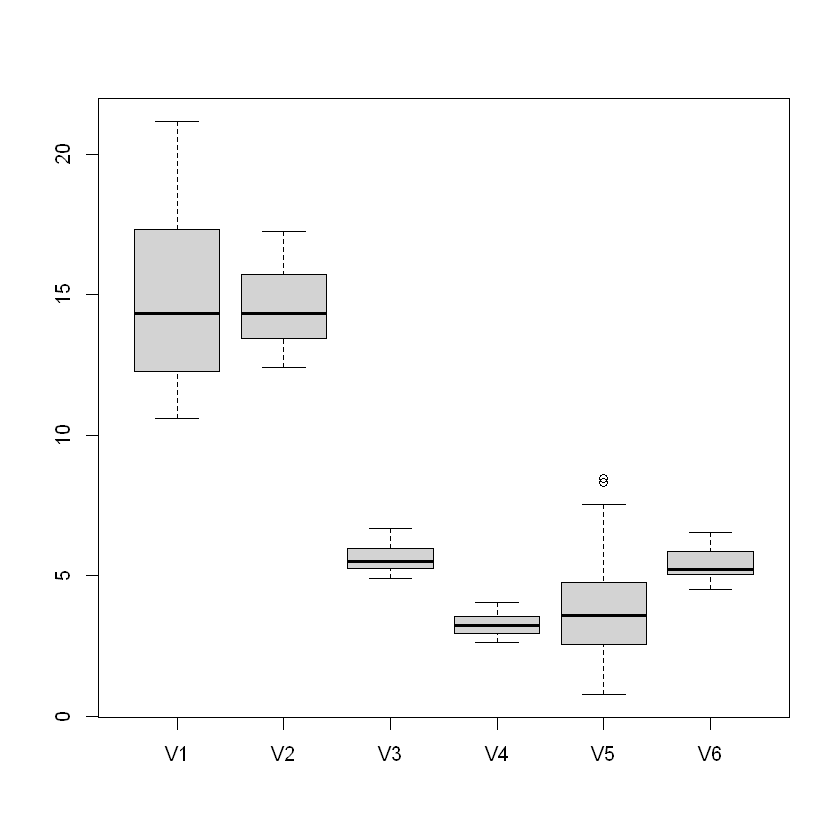

In [2]:
# Carga datos Ejercicio 1
#ruta datos
#lee datos del archivo de texto como una matriz. La primera #columna se utiliza como vector de nombres de las filas
datos1 <- read.table("semillas1.txt", dec = ".")

print(datos1[1:10,])
summary(datos1)
boxplot(datos1)

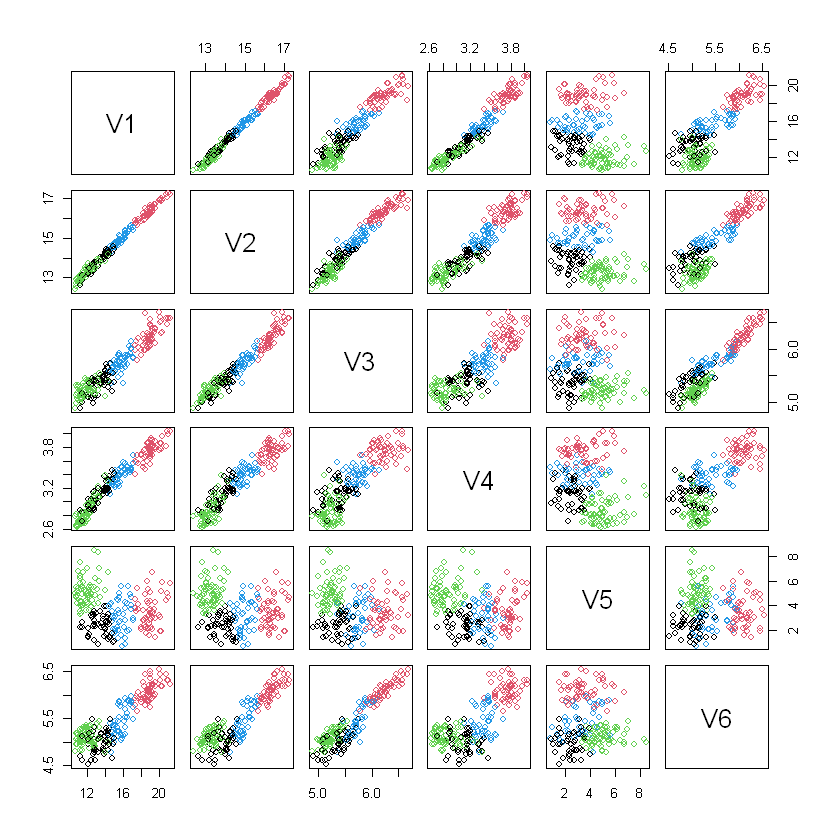

In [3]:
#ingresar valor de k0 
k0=4
cl<-kmeans(datos1,k0,iter.max=1000,nstart=10)
#grafica los datos coloreados con el grupo asignado en planos de pares de variables
pairs(datos1,col=cl$cluster)

Call:
princomp(x = datos1, cor = TRUE)

Standard deviations:
    Comp.1     Comp.2     Comp.3     Comp.4     Comp.5     Comp.6 
2.16788117 1.00229308 0.49446476 0.20713724 0.08426551 0.03461094 

 6  variables and  210 observations.


,Comp.1,Comp.2,Comp.3,Comp.4,Comp.5,Comp.6
1,-1.1731198,1.0501576,0.10256003,0.05800065,-0.0041432679,0.001410480
2,3.0936321,-0.2499533,-0.04446158,-0.04386905,0.0115749668,0.013458399
3,-2.1376924,-0.7392228,-0.11677986,-0.03800567,-0.0009242843,0.005265824
4,0.6362517,0.3177031,0.12251442,0.05021075,-0.0084876163,-0.025890456


K-means clustering with 4 clusters of sizes 46, 54, 66, 44

Cluster means:
        V1       V2       V3       V4       V5       V6
1 13.39109 13.86522 5.366000 3.114283 2.415804 4.990674
2 18.96296 16.39667 6.242722 3.749926 3.540333 6.100778
3 11.91439 13.26152 5.231227 2.863939 5.068288 5.105348
4 15.71909 14.97659 5.745182 3.398500 3.187045 5.448386

Clustering vector:
  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 
  4   2   4   3   4   1   4   1   2   1   3   4   4   4   2   3   3   4   4   3 
 21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40 
  3   2   4   3   3   4   3   1   1   2   4   1   3   4   2   2   2   3   4   3 
 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60 
  1   3   2   1   3   2   2   3   3   3   2   1   4   3   4   1   4   4   2   3 
 61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80 
  1   2   1   4   2   1   2   4   2   3   2   1   4   2   

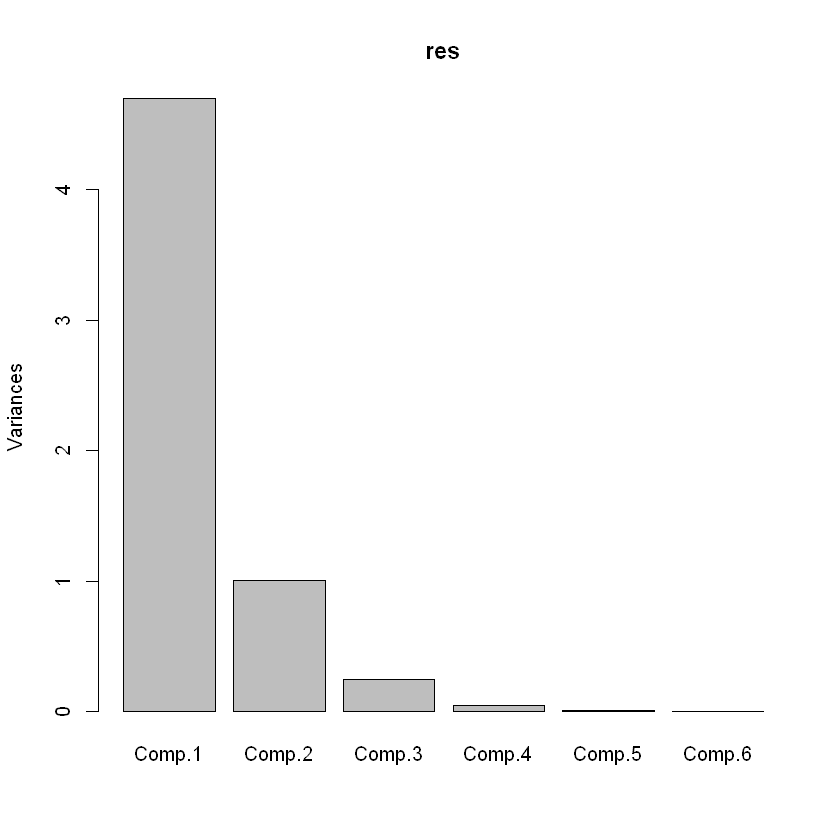

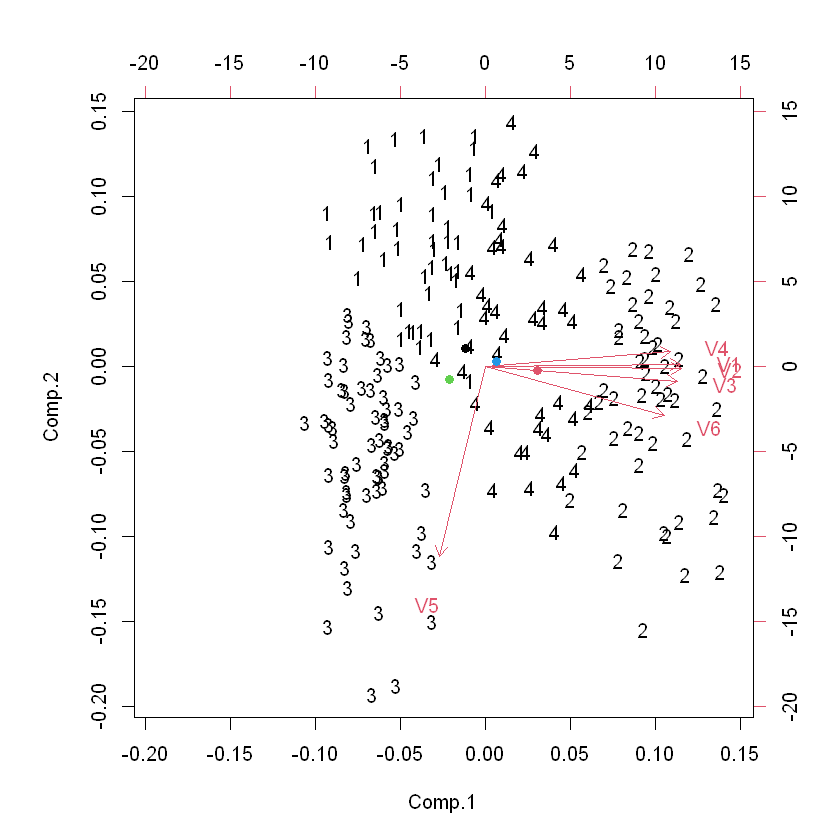

In [4]:
#Análisis de Componentes Principales para graficar los grupos obtenidos
#Calcula plano de componentes principales y grafica las observaciones con el número de su grupo
res <- princomp(datos1, cor=TRUE)
print(res)
plot(res)
res2 <- predict(res,cl$centers)
res2
cl
biplot(res,xlabs=cl$cluster)
#grafica los centros de cada grupo en el plano de componentes principales utilizando colores distintos
points(res2[,1:2],col=1:k0,pch=19)

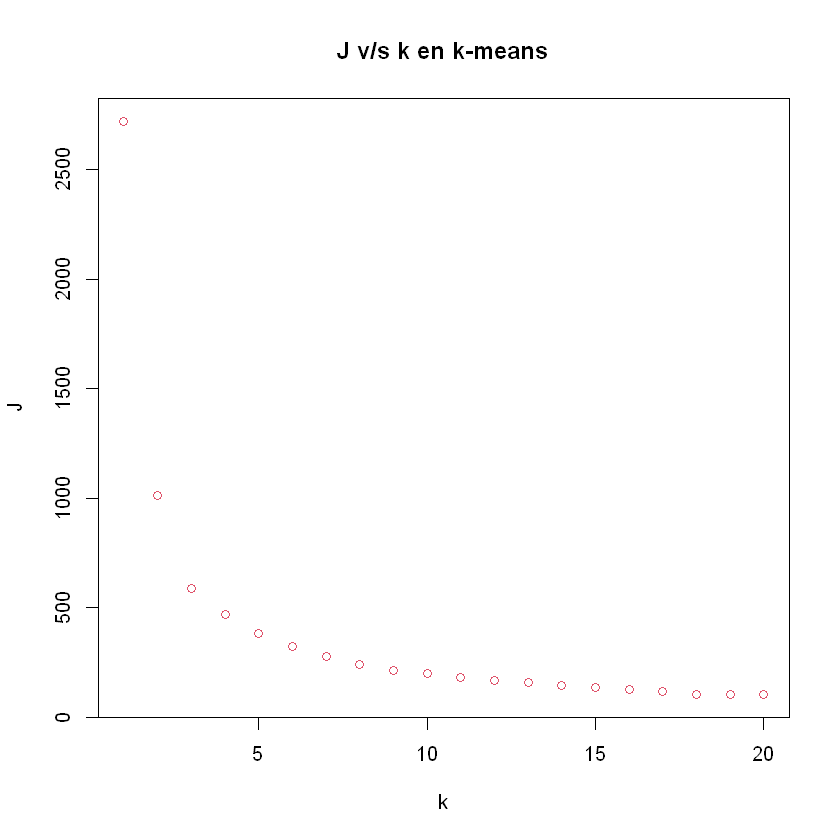

In [5]:
#Estrategia para elegir K, el numero de grupos
#J suma cuadrado de las distancias por cada k utilizado
#K-means
J<-rep(0,20)
fin_iter<-20


for (k in 1:fin_iter){
     cl<-kmeans(datos1,k,iter.max=1000,nstart=10)
	 J[k]<-cl$tot.withinss
}


plot(1:fin_iter,J,xlab="k",ylab="J",type="p",main="J v/s k en k-means",col=2) 

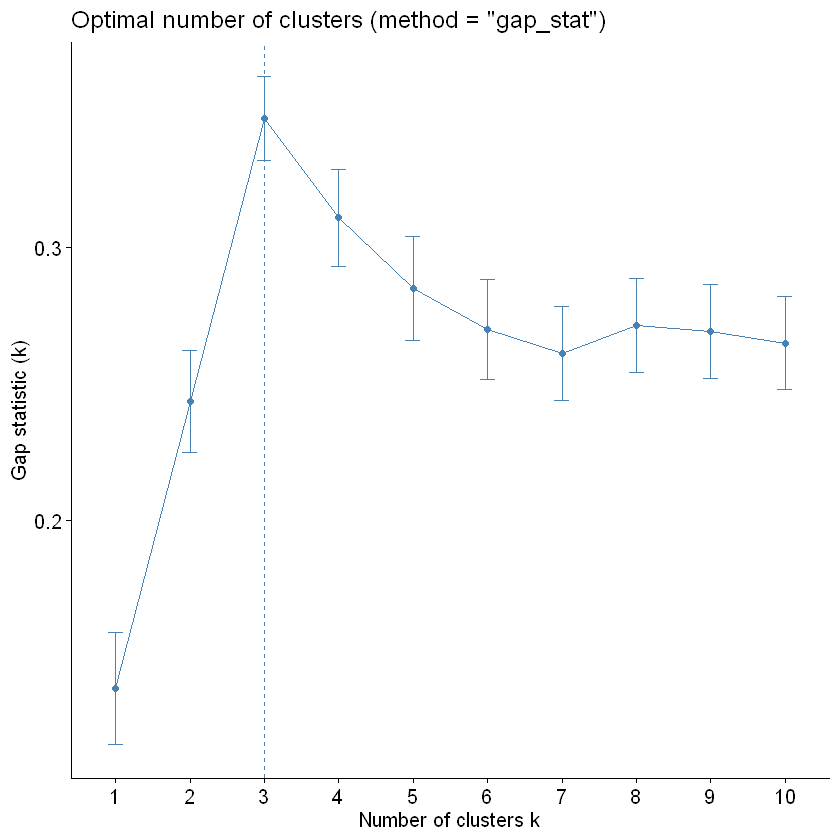

In [6]:
df1 <- data.frame(datos1)
gap_stat <- clusGap(df1,
                    FUN = kmeans,
                    nstart = 25,
                    K.max = 10,
                    B = 50)


fviz_gap_stat(gap_stat)

## Pregunta 1
###  - De acuerdo al gráfico obtenido, cuál es el valor de K mas apropiado? Explique su decisión.

#### Se selecciona (K=3) porque corresponde al punto de inflexión del método del codo (pendiente decrece fuértemente hasta este punto, más suavemente después de ese punto) y coincide con el mayor valor del gap statistic, indicando un buen equilibrio entre compactación de grupos y complejidad del modelo.

## Pregunta 2
### - Realice nuevamente los cálculos con el K óptimo y  caracterice los grupos obtenidos. Interprete sus resultados

#### Se recalcula k-means con K=3

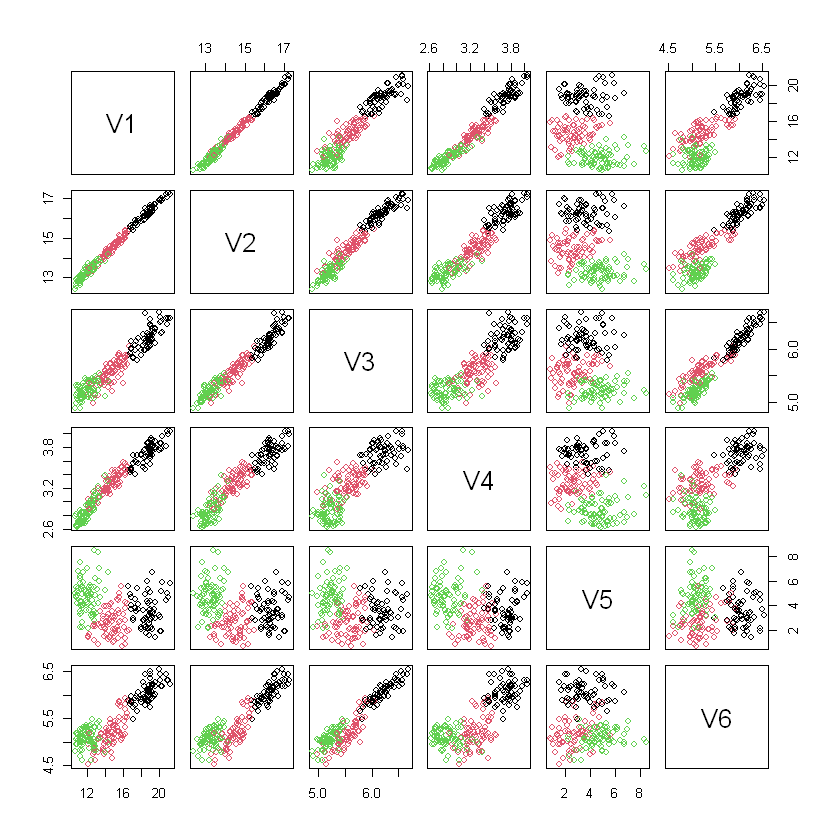

In [7]:
#ingresar valor de k0 
k_opt1 <- 3
cl<-kmeans(datos1,k_opt1,iter.max=1000,nstart=10)
#grafica los datos coloreados con el grupo asignado en planos de pares de variables
pairs(datos1,col=cl$cluster)

Call:
princomp(x = datos1, cor = TRUE)

Standard deviations:
    Comp.1     Comp.2     Comp.3     Comp.4     Comp.5     Comp.6 
2.16788117 1.00229308 0.49446476 0.20713724 0.08426551 0.03461094 

 6  variables and  210 observations.


,Comp.1,Comp.2,Comp.3,Comp.4,Comp.5,Comp.6
1,2.9205042,-0.2730151,-0.03930464,-0.04246970,0.010152392,0.007972724
2,-0.2189232,0.7985683,0.16423218,0.08015012,-0.010906320,-0.014971476
3,-2.1089388,-0.5304285,-0.12243032,-0.04130075,0.002155313,0.007683248


K-means clustering with 3 clusters of sizes 61, 72, 77

Cluster means:
        V1       V2       V3       V4       V5       V6
1 18.72180 16.29738 6.208934 3.722672 3.603590 6.066098
2 14.64847 14.46042 5.563778 3.277903 2.648931 5.192319
3 11.96442 13.27481 5.229286 2.872922 4.759740 5.088519

Clustering vector:
  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20 
  2   1   2   3   2   2   2   2   1   2   3   2   2   1   1   3   3   2   2   3 
 21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40 
  3   1   2   3   3   1   3   2   2   1   2   2   3   2   1   1   1   3   2   3 
 41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60 
  3   3   1   2   3   1   1   3   3   3   1   3   2   3   2   2   1   2   1   3 
 61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80 
  2   1   3   2   1   2   1   2   1   3   1   2   2   1   2   1   2   1   2   1 
 81  82  83  84  85  86  87  88  89  

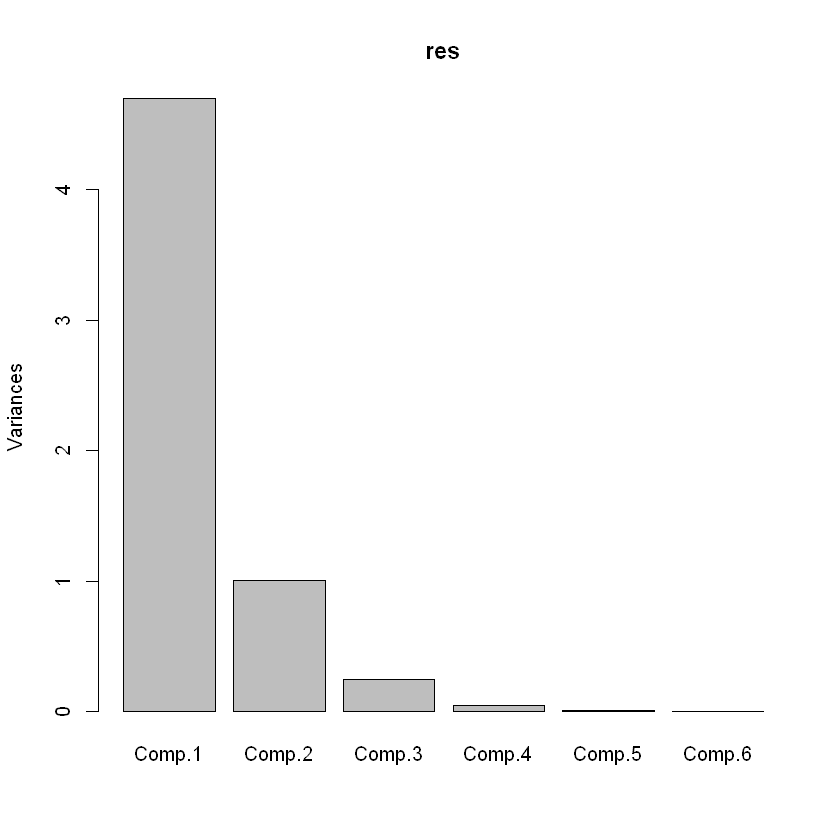

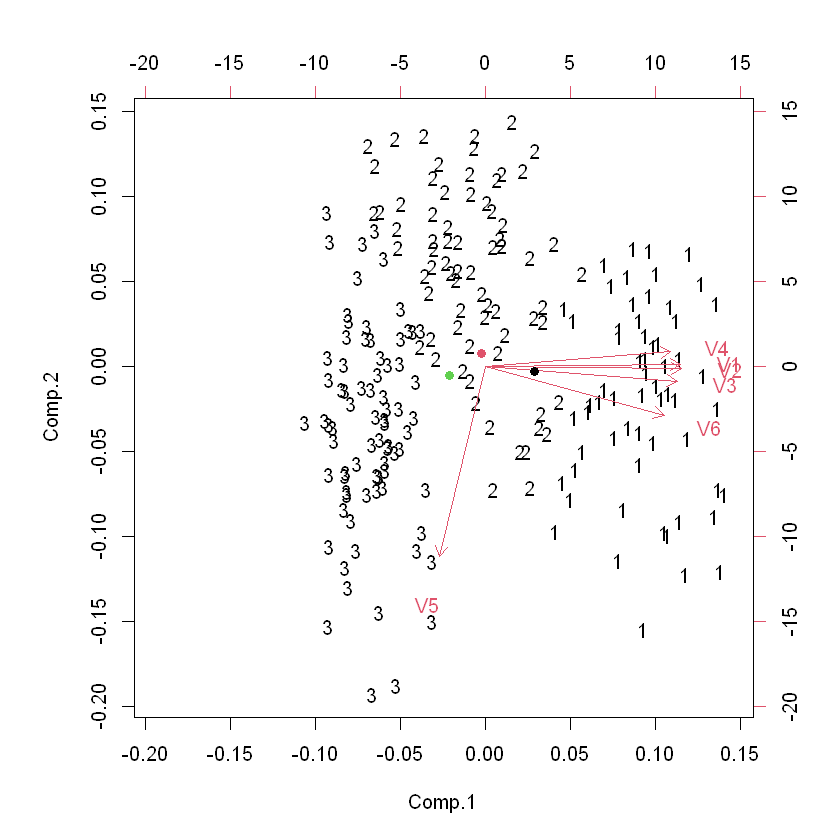

In [8]:
#Análisis de Componentes Principales para graficar los grupos obtenidos
#Calcula plano de componentes principales y grafica las observaciones con el número de su grupo
res <- princomp(datos1, cor=TRUE)
print(res)
plot(res)
res2 <- predict(res,cl$centers)
res2
cl
biplot(res,xlabs=cl$cluster)
#grafica los centros de cada grupo en el plano de componentes principales utilizando colores distintos
points(res2[,1:2],col=1:k0,pch=19)

#### La caracterización por centroides en escala original evidencia un grupo de menor nivel, uno intermedio y uno de mayor nivel en las variables clave, por lo que la solución de 3 clusters resulta útil para segmentación.

In [9]:
# K-means con k optimo (cambiar segun el grafico anterior)
cl1 <- kmeans(datos1, k_opt1, iter.max = 1000, nstart = 10)
cat("Centros de los grupos:\n")
print(cl1$centers)
cat("\nTamaño de los grupos:\n")
print(table(cl1$cluster))

Centros de los grupos:
        V1       V2       V3       V4       V5       V6
1 11.96442 13.27481 5.229286 2.872922 4.759740 5.088519
2 14.64847 14.46042 5.563778 3.277903 2.648931 5.192319
3 18.72180 16.29738 6.208934 3.722672 3.603590 6.066098

Tamaño de los grupos:

 1  2  3 
77 72 61 


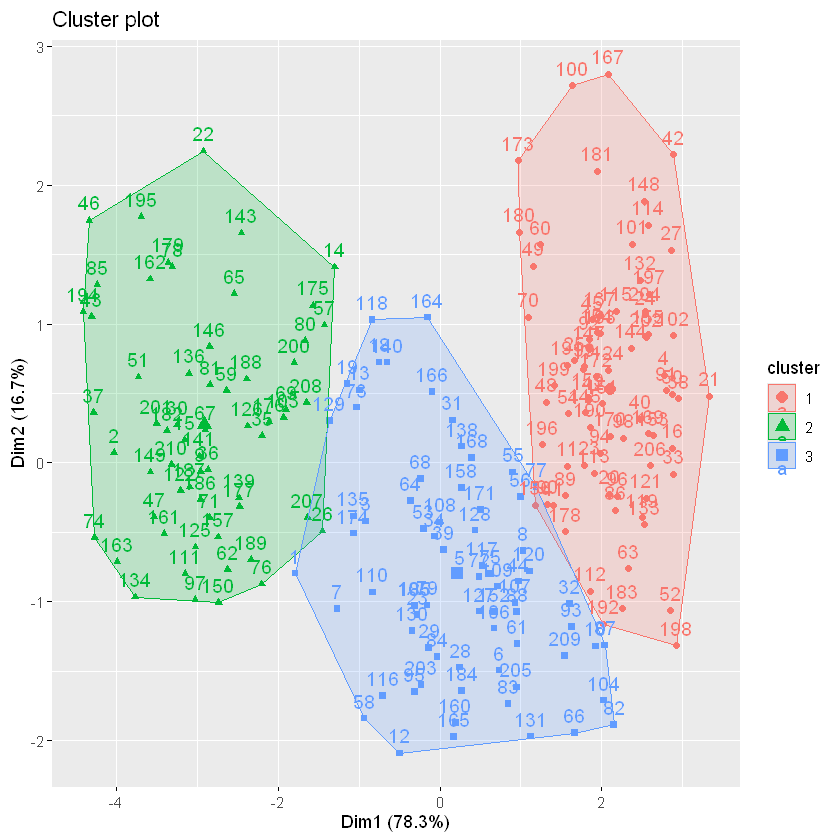

In [10]:
#install.packages("factoextra")

# 2. Load the library
library(factoextra)

df1 <- data.frame(datos1)
k0=3
cl<-kmeans(datos1,k0,iter.max=1000,nstart=10)
fviz_cluster(cl, df1)

#### La segmentación obtenida muestra tres claros grupos con separación principalmente en la primera componente principal (Dim1), validando que la elección de K=3 es correcta.

## Ejercicio 2: Grupo16.csv
## Realice un análisis de clustering con el conjunto de datos correspondiente a su grupo, para el cual ya realizó un análisis exploratorio y de PCA (No olvide de excluir la penúltima y última columna de sus datos originales).

### Describa los datos y discuta la pertinencia de realizar un análisis de clustering o agrupamiento

# Respuesta

## a) El conjunto de datos de clientes presenta las siguientes características:

- **Frecuencia (Media: 5.07)**  
  Indica el número de compras. La distribución es asimétrica con una cola derecha (máx 16.49), lo que sugiere un grupo de clientes de alta frecuencia.

- **Gasto (Media: 62.97)**  
  Es la variable con mayor dispersión. Presenta un rango muy amplio, incluyendo valores negativos (mín -189.9, probablemente ajustes o devoluciones masivas) y un máximo de 277.54. Esto indica una alta heterogeneidad en el valor económico de los clientes.

- **Visitas (Media: 42.74)**  
  Número de visitas a la plataforma. Similar a frecuencia, muestra una cola larga hacia la derecha (máx 158.36).

- **Devoluciones (Media: 2.21)**  
  Presenta un rango que va desde valores negativos (-4.15) hasta 13.57.

- **Satisfacción Cliente (Media: 1.47)**  
  Un puntaje que va de 0.01 a 5.74.

---

## b) Realizar un análisis de clustering sobre estos datos es altamente pertinente por las siguientes razones:

1. **Segmentación de Mercado No Supervisada**  
   El objetivo de negocio subyacente es la segmentación de clientes.  
   Dado que no tenemos etiquetas predefinidas de "clientes VIP" o "clientes en riesgo", el clustering es la técnica ideal para descubrir grupos naturales basados en:
   - Comportamiento de compra (frecuencia, gasto)  
   - Interacción (visitas)  
   - Feedback (devoluciones, satisfacción_cliente)

2. **Estructura de Datos Subyacente**  
   El análisis PCA realizado previamente demostró que las primeras componentes principales explican una porción significativa de la varianza (~60%).  
   Esto confirma que los datos no son ruido aleatorio; existe una estructura de correlación (ej. gasto correlacionado con satisfacción) que un algoritmo de clustering puede explotar para encontrar agrupaciones significativas.

3. **Variables con Poder Discriminante**  
   La presencia de variables con distribuciones sesgadas y valores atípicos (gasto, visitas) es una característica ideal para el clustering.  
   El algoritmo **K-Means** es sensible a la magnitud, por lo que estas diferencias en escala y varianza ayudarán a separar naturalmente a los clientes de alto valor de los de bajo valor.


   frecuencia            gasto             visitas          devoluciones    
 Min.   :-2.962738   Min.   :-6.04027   Min.   :-2.37513   Min.   :-3.3293  
 1st Qu.:-0.644700   1st Qu.:-0.51980   1st Qu.:-0.64245   1st Qu.:-0.6446  
 Median :-0.002352   Median :-0.05603   Median :-0.01972   Median :-0.1338  
 Mean   : 0.000000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.: 0.647975   3rd Qu.: 0.49564   3rd Qu.: 0.54152   3rd Qu.: 0.5052  
 Max.   : 4.557919   Max.   : 5.12559   Max.   : 4.52816   Max.   : 5.9532  
 satisfaccion_cliente
 Min.   :-1.7074     
 1st Qu.:-0.6348     
 Median :-0.2656     
 Mean   : 0.0000     
 3rd Qu.: 0.3850     
 Max.   : 5.0092     

frecuencia                gasto              visitas 
                   1                    1                    1 
        devoluciones satisfaccion_cliente 
                   1                    1

frecuencia                      gasto 
-0.00000000000000016511600  0.00000000000000003968572 
                   visitas               devoluciones 
-0.00000000000000013563346 -0.00000000000000005485298 
      satisfaccion_cliente 
 0.00000000000000010149228

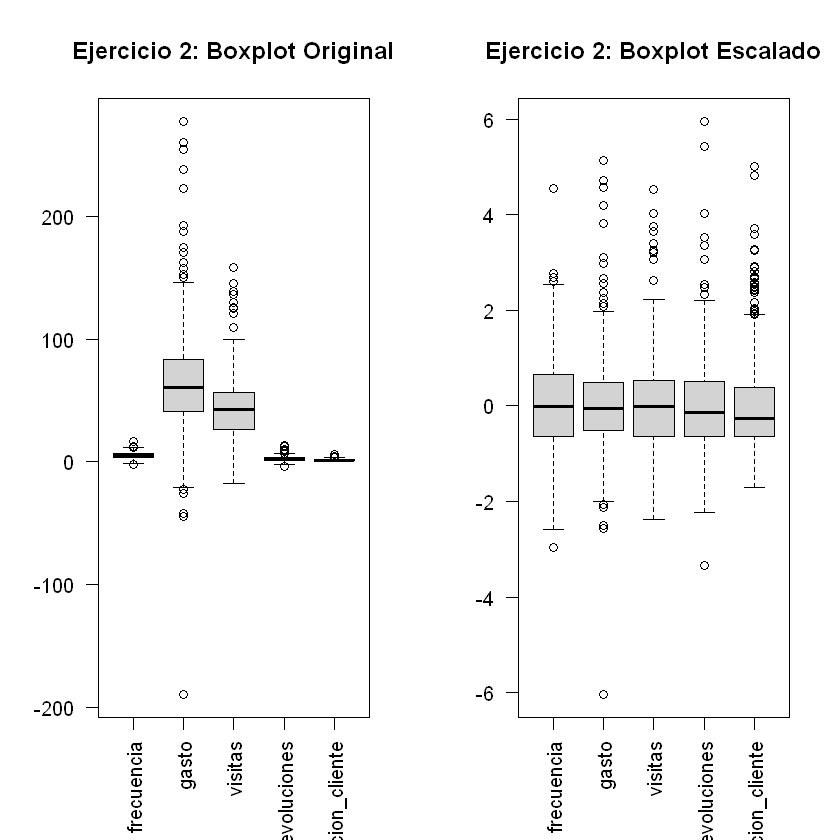

In [11]:
# Carga datos Ejercicio 2 (sin penultima y ultima columna)
datos2_raw <- read.csv("Grupo16.csv", header = TRUE, sep = ";")
datos2 <- datos2_raw[, 1:(ncol(datos2_raw) - 2)]
datos2 <- datos2[, sapply(datos2, is.numeric), drop = FALSE]
datos2 <- datos2[complete.cases(datos2), , drop = FALSE]

# Normalizacion
scaled_df2 <- apply(datos2, 2, scale)
summary(scaled_df2)
apply(scaled_df2, 2, var)
apply(scaled_df2, 2, mean)

# Grafico 1: boxplots antes y despues de normalizar
par(mfrow = c(1, 2))
boxplot(datos2, main = "Ejercicio 2: Boxplot Original", las = 2)
boxplot(scaled_df2, main = "Ejercicio 2: Boxplot Escalado", las = 2)
par(mfrow = c(1, 1))

### Utilice k-means para realizar el clustering de los datos y calcule el K óptimo.

# Respuesta

## Preprocesamiento de Datos
Se escalaron los datos del archivo **Grupo16.csv** para que todas las variables  
(*frecuencia, gasto, visitas, devoluciones, satisfacción_cliente*) tuvieran el mismo peso,  
dado que sus escalas originales eran muy diferentes.

## Aplicación de K-means
Se aplicó el algoritmo **K-means** para diferentes valores de $K$ y se evaluó el número óptimo de grupos utilizando dos métodos principales:

- **Método del Codo** (basado en la suma de cuadrados intra-grupo, J)  
- **Estadístico de Brecha** (*Gap Statistic*)

---

## Resultados

### Método del Codo (J vs k)
El gráfico generado (*Ejercicio 2: J vs k en k-means*) muestra una curva suave y decreciente.  
A diferencia del Ejercicio 1, no se observa un punto de inflexión claro o "codo" que indique de manera contundente un número óptimo de grupos.  
La suma de cuadrados intra-grupo disminuye de forma continua a medida que aumenta $K$, lo cual es esperable pero dificulta la elección de un $K$ específico.

### Estadístico de Brecha (Gap Statistic)
El análisis de `clusGap` y su gráfica correspondiente proporciona una respuesta más concreta.  
El valor del estadístico de brecha se maximiza para $K = 1$.  

Esto indica que, estadísticamente, la estructura de agrupamiento más significativa es aquella que considera todos los datos como un único grupo.  
En otras palabras, el algoritmo no encuentra una partición en múltiples grupos que sea significativamente mejor que una distribución de referencia sin grupos.

---

## Conclusión sobre el K Óptimo
- El método del **Codo** no es concluyente.  
- El **Gap Statistic** sugiere que $K = 1$ es el valor óptimo.  

Este resultado indica que, con los datos disponibles y después de la normalización, los clientes no se agrupan de forma natural en segmentos claramente diferenciados.  
Todos los puntos tienden a formar una única nube homogénea en el espacio de características.


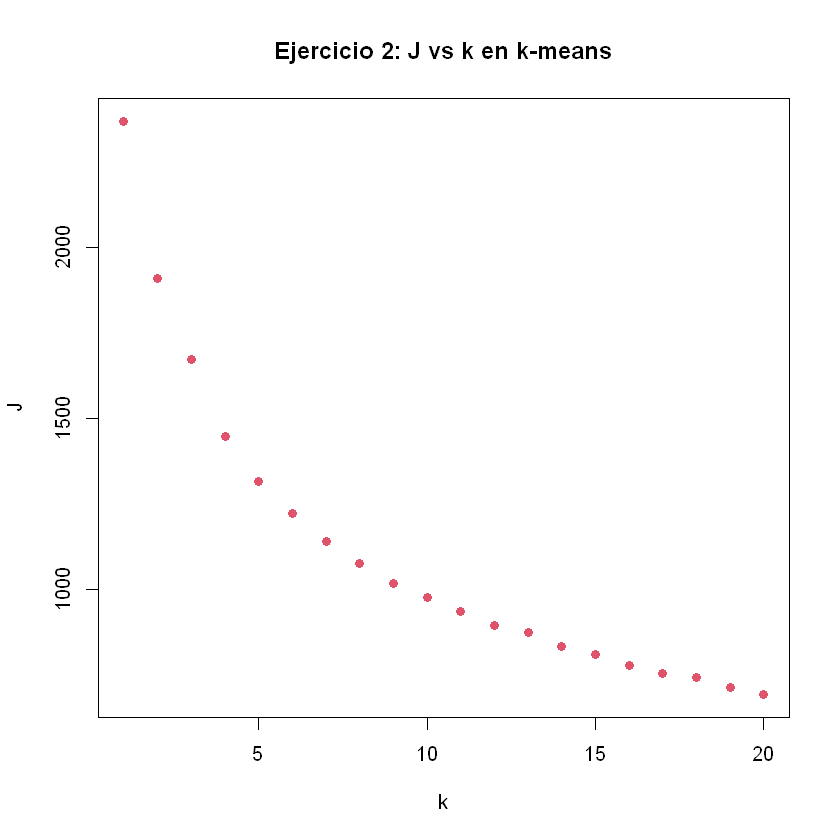

In [12]:
# Grafico J vs k para elegir k optimo
J2 <- rep(0, 20)
fin_iter2 <- 20
for (k in 1:fin_iter2) {
  cl_temp <- kmeans(scaled_df2, k, iter.max = 1000, nstart = 10)
  J2[k] <- cl_temp$tot.withinss
}
plot(1:fin_iter2, J2, xlab = "k", ylab = "J", type = "p",
     main = "Ejercicio 2: J vs k en k-means", col = 2, pch = 19)

Gráfico J vs K en K-means no indica fuerte cambio de pendiente.

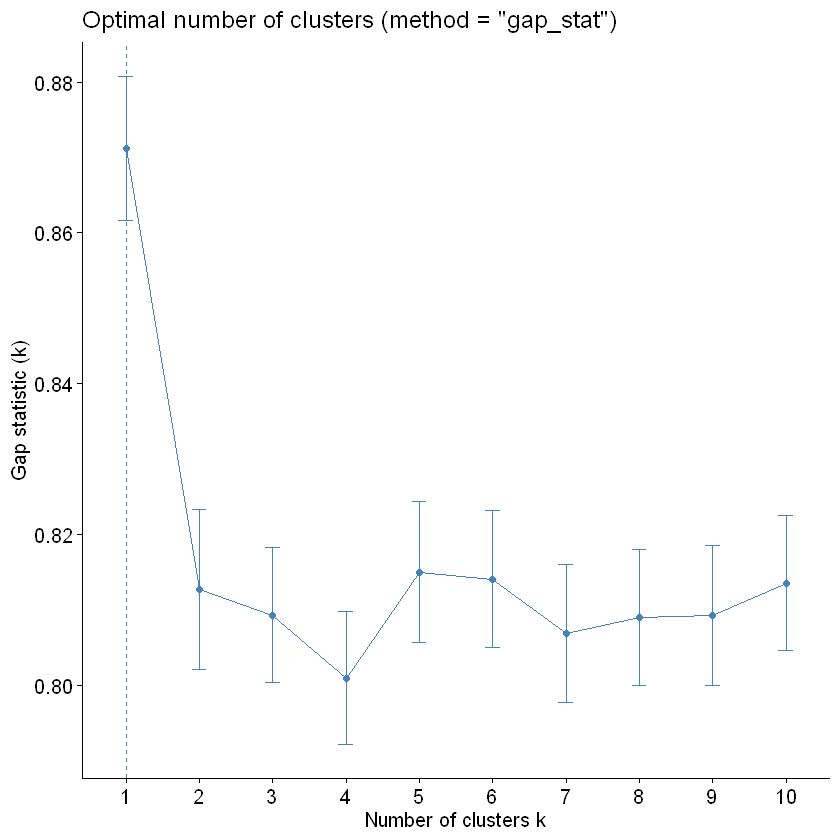

In [13]:
#calculo de gap estadístico basado en el número de grupos: 
#tasa entre la suma de distancias intragrupos con k grupos y con un sólo un grupo
df2 <- data.frame(scaled_df2)
gap_stat <- clusGap(df2,
                    FUN = kmeans,
                    nstart = 25,
                    K.max = 10,
                    B = 50)


fviz_gap_stat(gap_stat)

El método de gap statistic sugiere (k=1), indicando ausencia de grupos claramente separados.

### Caracterice los grupos obtenidos con el K óptimo. Interprete sus resultados

# Respuesta

## Caracterización del Grupo con K Óptimo (K=1)

El centro del grupo único (escalado) corresponde al **centroide de todos los datos**, es decir, la media de las variables originales.

### Centro del Grupo (Valores Originales Aproximados)

| Variable            | Valor Promedio |
| :------------------ | --------------:|
| **Frecuencia**      | ~5.07          |
| **Gasto**           | ~62.97         |
| **Visitas**         | ~42.74         |
| **Devoluciones**    | ~2.21          |
| **Satisfacción**    | ~1.47          |

**Tamaño del Grupo:** 475 (100% de la muestra de clientes)

---

## Interpretación de los Resultados

El hecho de que el análisis estadístico (Gap Statistic) indique que **K=1** es la opción óptima tiene una interpretación de negocio muy clara:

1. **Ausencia de Segmentos Naturales Claros**  
   A diferencia de lo esperado en una segmentación típica (VIP, promedio, en riesgo), este conjunto de datos no presenta una estructura de grupos bien definida.

2. **Comportamiento Homogéneo**  
   Los 475 clientes se comportan como una **nube de puntos homogénea** en el espacio de las 5 variables. Aunque existen diferencias individuales, estas forman un continuo sin fronteras claras que justifiquen dividir la base en clusters.

3. **Implicaciones de Negocio**
   - **Evitar la Sobresegmentación:** Forzar una partición en múltiples grupos (K=3, K=4) generaría clusters artificiales e inestables.  
   - **Estrategia de “Talla Única” Mejorada:** En lugar de campañas hiper-segmentadas, puede ser más eficaz aplicar una **personalización continua** (modelos de regresión, scoring RFM).  
   - **Limitación de las Variables:** Las variables usadas (frecuencia, gasto, visitas, devoluciones, satisfacción) no son suficientes para discriminar entre tipos de clientes. Se necesitarían datos adicionales (demográficos, categorías de producto, canal de adquisición, antigüedad).

---

## Conclusión
El análisis converge en que el número óptimo de clusters es:



\[
K = 1
\]



Esto refleja un comportamiento homogéneo de la base de clientes y sugiere que las estrategias deben orientarse hacia la personalización individual más que hacia la segmentación en grupos discretos.


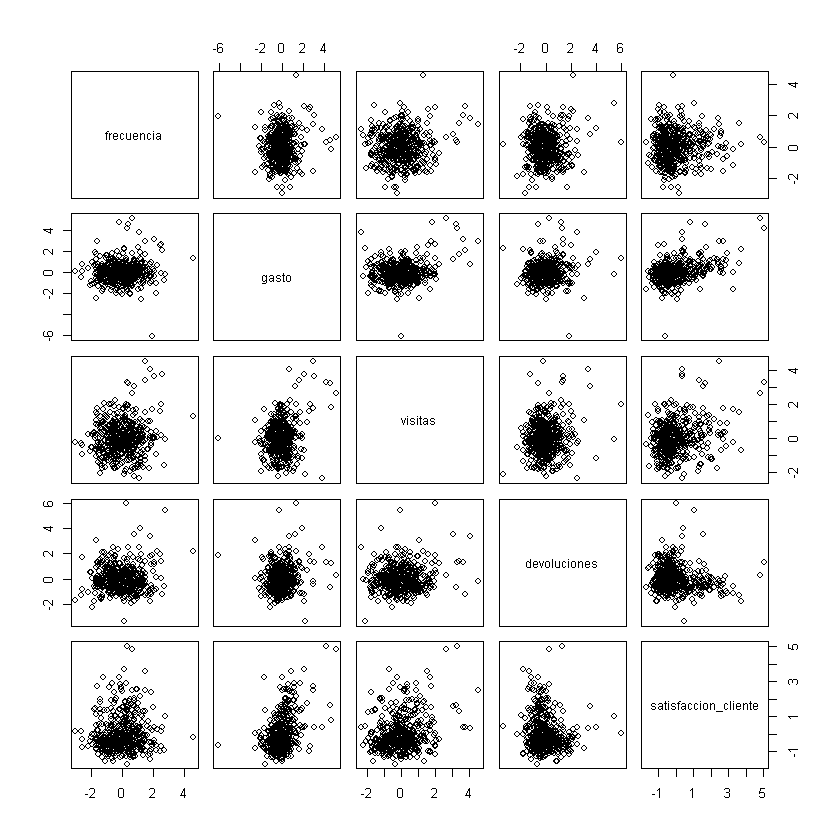

In [24]:
#ingresar valor de k0 
k0=1
cl<-kmeans(df2,k0,iter.max=1000,nstart=10)
#grafica los datos coloreados con el grupo asignado en planos de pares de variables
pairs(scaled_df2,col=cl$cluster)

Call:
princomp(x = X_pca, cor = TRUE)

Standard deviations:
   Comp.1    Comp.2    Comp.3    Comp.4    Comp.5 
1.2760722 1.0549103 0.9768187 0.8795979 0.7286541 

 5  variables and  475 observations.


,Comp.1,Comp.2,Comp.3,Comp.4,Comp.5
1,0.000000000000001206801,0.0000000000000002232104,-0.0000000000000003533455,-0.0000000000000001292637,0.00000000000000046055


K-means clustering with 1 clusters of sizes 475

Cluster means:
  frecuencia    gasto  visitas devoluciones satisfaccion_cliente
1   5.065895 62.96577 42.74356     2.205516             1.466589

Clustering vector:
  1   2   3   4   5   6   7   8   9  10  11  12  13  15  16  17  18  19  21  22 
  1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1 
 23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42 
  1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1 
 43  44  45  46  47  48  49  50  52  53  54  55  56  57  58  59  60  61  62  63 
  1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1 
 64  65  66  67  68  69  70  71  73  74  75  76  77  78  79  80  81  82  83  84 
  1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1 
 85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 
  1   1   1   1   1   1   1   1   1   1   1   1   1   1  

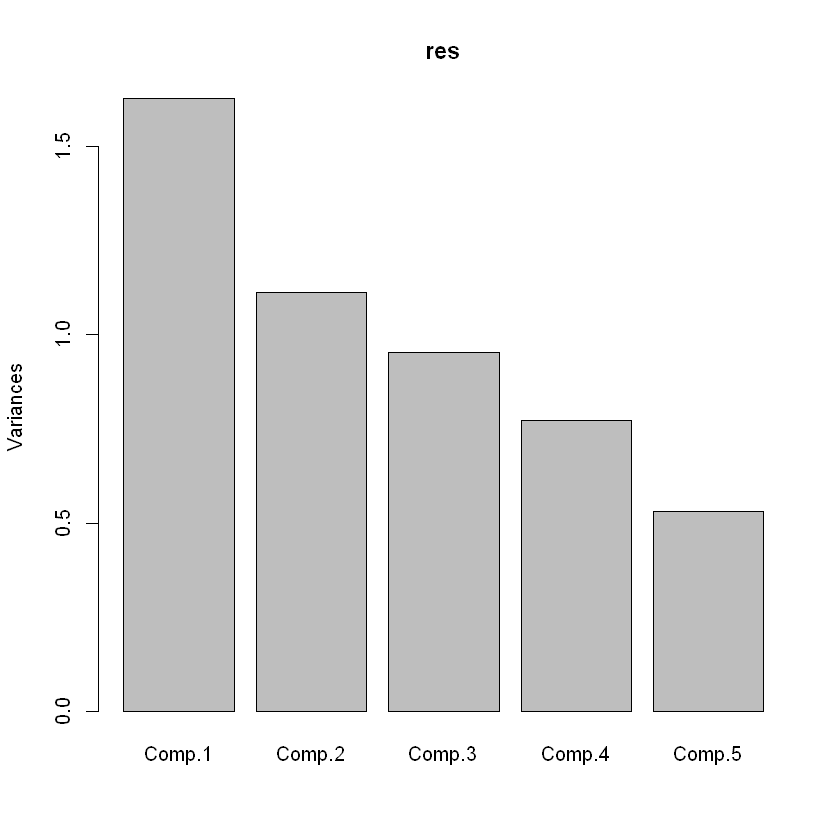

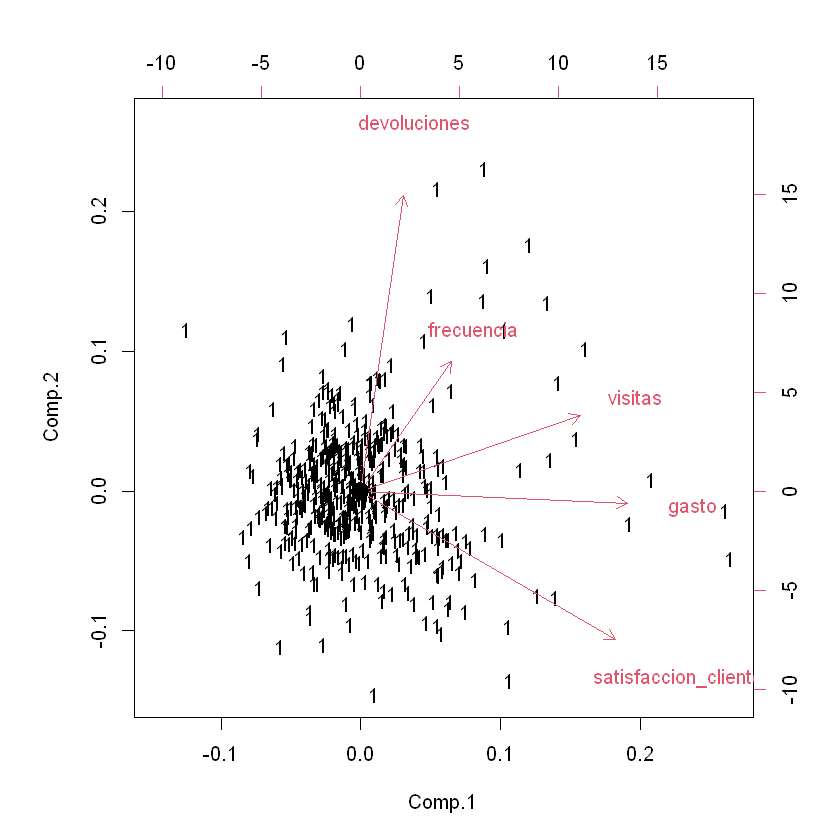

In [25]:
#Análisis de Componentes Principales para graficar los grupos obtenidos
#Calcula plano de componentes principales y grafica las observaciones con el número de su grupo
# Usa la misma matriz que k-means para evitar desajustes de columnas
X_pca <- as.data.frame(df2)

res <- princomp(X_pca, cor = TRUE)
print(res)
plot(res)

# Asegura que newdata tenga mismo número, nombre y orden de columnas
centros <- as.data.frame(cl$centers)
centros <- centros[, names(res$center), drop = FALSE]

res2 <- predict(res, newdata = centros)
res2
cl
biplot(res, xlabs = cl$cluster)
#grafica los centros de cada grupo en el plano de componentes principales utilizando colores distintos
points(res2[,1], res2[,2], col = 1:k0, pch = 19, cex = 2)

In [26]:
# K-means con k optimo (cambiar segun el grafico anterior)
k_opt2 <- 1
cl2 <- kmeans(df2, k_opt2, iter.max = 1000, nstart = 10)
cat("Centros de los grupos:\n")
print(cl2$centers)
cat("\nTamano de los grupos:\n")
print(table(cl2$cluster))

Centros de los grupos:
  frecuencia    gasto  visitas devoluciones satisfaccion_cliente
1   5.065895 62.96577 42.74356     2.205516             1.466589

Tamano de los grupos:

  1 
475 


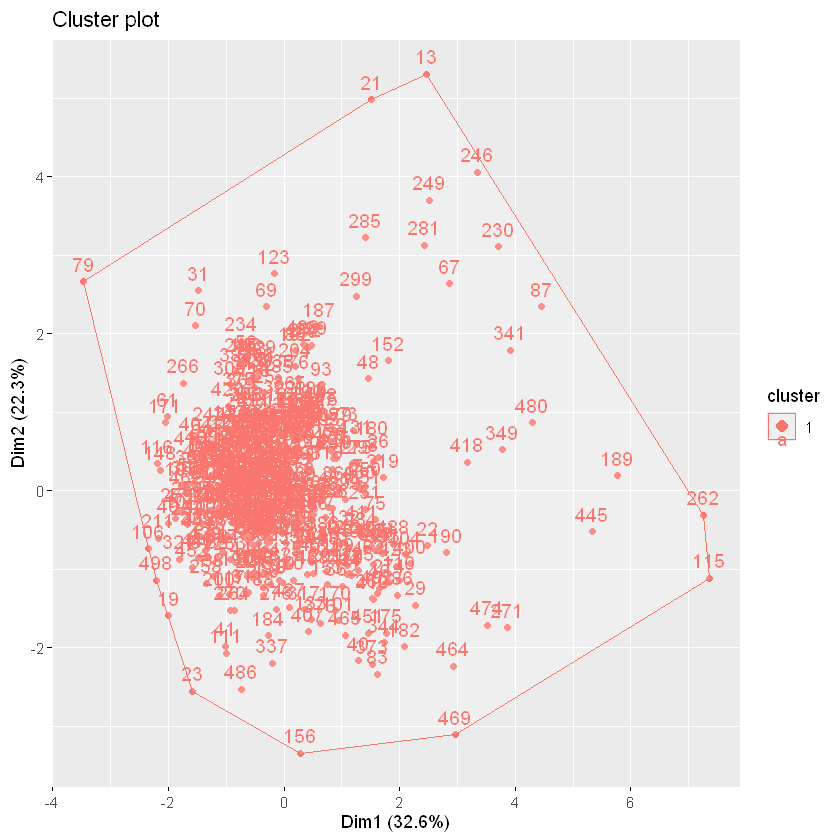

In [27]:
df2 <- data.frame(datos2)
fviz_cluster(cl2, df2)

Centros de los grupos:
  frecuencia    gasto  visitas devoluciones satisfaccion_cliente
1   5.256667 99.56414 46.56226     2.501183             1.817258
2   4.943114 39.41111 40.28585     2.015225             1.240900

Tamano de los grupos:

  1   2 
186 289 


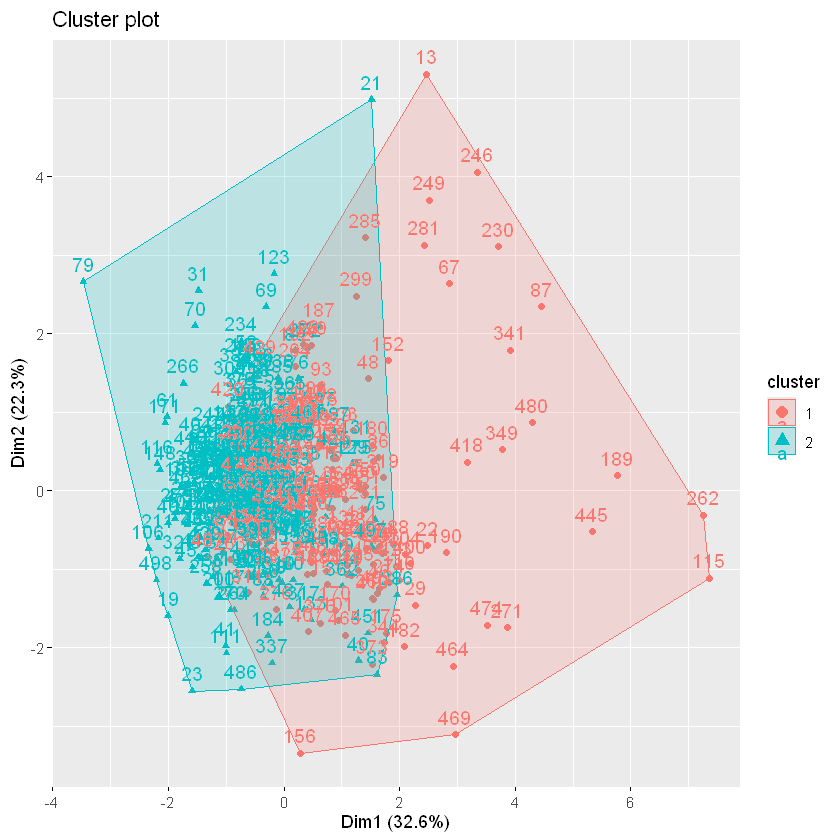

In [28]:
# K-means con k optimo (cambiar segun el grafico anterior)
k_opt2 <- 2
cl2 <- kmeans(df2, k_opt2, iter.max = 1000, nstart = 10)
cat("Centros de los grupos:\n")
print(cl2$centers)
cat("\nTamano de los grupos:\n")
print(table(cl2$cluster))

df2 <- data.frame(datos2)
fviz_cluster(cl2, df2)